In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

In [3]:
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [4]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [7]:
path = kagglehub.dataset_download('satyakidas07/retail-sales-dataset')
df = pd.read_csv(f'{path}/retail_sales_dataset.csv')

100%|██████████| 190k/190k [00:00<00:00, 395kB/s]

Extracting files...


In [8]:
df.head()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,...,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,...,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,...,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,...,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,...,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0


In [9]:
df.tail()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
4305,ORD-00056,2020-01-21,CUST85136,Sanjay Sharma,45.0,F,West,Pune,Sports,Football,...,1871.46,0.22,6895.34,1811.03,62.59,EMI,NaN,True,Returned,9.0
4306,ORD-03458,2024-02-08,CUST09746,Karan Pillai,25.0,m,South,Chennai,Clothing,Kurta,...,3147.97,0.13,22125.94,10153.44,38.76,EMI,2.0,False,Cancelled,2.0
4307,ORD-01769,2022-02-22,CUST64190,Karan Reddy,39.0,Male,East,Guwahati,Beauty,Face Cream,...,422.45,0.02,2726.49,759.36,39.41,Credit Card,NaN,False,Delivered,5.0
4308,ORD-01738,2022-02-11,CUST50460,Amit Mehta,40.0,Female,East,Bhubaneswar,Books,Biography,...,1456.57,0.27,4835.66,2312.44,71.90,Cash on Delivery,1.0,False,Cancelled,4.0
4309,ORD-03241,2023-11-01,CUST36164,Nikhil Rao,23.0,Other,North,Delhi,Furniture,Desk,...,28349.81,0.14,211857.48,59966.21,53.88,Debit Card,2.0,False,Delivered,2.0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               4280 non-null   object        
 1   order_date             4007 non-null   datetime64[ns]
 2   customer_id            4280 non-null   object        
 3   customer_name          4280 non-null   object        
 4   age                    4150 non-null   float64       
 5   gender                 4280 non-null   object        
 6   region                 4280 non-null   object        
 7   city                   4280 non-null   object        
 8   product_category       4280 non-null   object        
 9   product_name           4280 non-null   object        
 10  quantity               4170 non-null   float64       
 11  unit_price             4280 non-null   float64       
 12  discount_pct           4143 non-null   float64       
 13  sal

In [13]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce")

In [15]:
df.describe()

,order_date,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship
count,4007,4150.000000,4170.000000,4280.000000,4143.000000,4.280000e+03,4.280000e+03,4280.000000,3932.000000,4180.000000
mean,2022-07-05 03:06:09.253805824,35.335181,7.379856,10621.154428,0.202085,6.235864e+04,1.168713e+04,63.358836,3.016531,5.620335
min,2020-01-01 00:00:00,-7.000000,-1.000000,50.260000,0.000000,3.945000e+01,1.560000e+00,-4.290000,1.000000,-1.000000
25%,2021-04-18 00:00:00,26.000000,3.000000,672.222500,0.100000,2.462165e+03,7.018225e+02,50.817500,2.000000,3.000000
50%,2022-07-10 00:00:00,34.000000,5.000000,2228.435000,0.210000,9.548075e+03,3.128005e+03,63.465000,3.000000,6.000000
75%,2023-09-27 12:00:00,42.000000,8.000000,12717.435000,0.310000,5.006964e+04,1.040372e+04,75.650000,4.000000,8.000000
max,2024-12-30 00:00:00,999.000000,999.000000,79957.920000,0.400000,1.736031e+07,2.445648e+06,133.350000,5.000000,100.000000
std,NaN,35.709382,43.578352,17323.704016,0.118095,3.166998e+05,5.287522e+04,18.312281,1.413127,4.178663


In [16]:
df.isnull()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4305,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4306,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4307,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4308,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [17]:
df.isnull().sum()

,0
order_id,30
order_date,303
customer_id,30
customer_name,30
age,160
gender,30
region,30
city,30
product_category,30
product_name,30


In [18]:
# Missing Value Treatment
# Numerical Columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
# Categorical Columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill Numerical Columns with Median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
# Fill Categorical Columns with Mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing Values After Treatment")
print(df.isnull().sum())

Missing Values After Treatment
order_id                   0
order_date               303
customer_id                0
customer_name              0
age                        0
gender                     0
region                     0
city                       0
product_category           0
product_name               0
quantity                   0
unit_price                 0
discount_pct               0
sales_amount               0
profit                     0
shipping_cost              0
payment_method             0
customer_satisfaction      0
return_flag                0
order_status               0
days_to_ship               0
dtype: int64


In [22]:
df.describe()

,order_date,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship
count,4310,4310.000000,4310.000000,4310.000000,4310.000000,4.310000e+03,4.310000e+03,4310.000000,4310.000000,4310.000000
mean,2022-07-05 11:19:14.338747136,35.285615,7.302552,10562.736427,0.202392,6.199105e+04,1.162755e+04,63.359575,3.015081,5.631787
min,2020-01-01 00:00:00,-7.000000,-1.000000,50.260000,0.000000,3.945000e+01,1.560000e+00,-4.290000,1.000000,-1.000000
25%,2021-05-20 12:00:00,26.000000,3.000000,680.682500,0.100000,2.474990e+03,7.127125e+02,50.902500,2.000000,3.000000
50%,2022-07-10 00:00:00,34.000000,5.000000,2228.435000,0.210000,9.548075e+03,3.128005e+03,63.465000,3.000000,6.000000
75%,2023-08-20 00:00:00,42.000000,8.000000,12596.057500,0.300000,4.925121e+04,1.023524e+04,75.487500,4.000000,8.000000
max,2024-12-30 00:00:00,999.000000,999.000000,79957.920000,0.400000,1.736031e+07,2.445648e+06,133.350000,5.000000,100.000000
std,NaN,35.041047,42.866650,17277.392296,0.115794,3.156260e+05,5.269564e+04,18.248425,1.349731,4.115659


In [20]:
df['order_date'] = df['order_date'].fillna(df['order_date'].median())
print("Missing Values After Order Date Treatment")
print(df.isnull().sum())

Missing Values After Order Date Treatment
order_id                 0
order_date               0
customer_id              0
customer_name            0
age                      0
gender                   0
region                   0
city                     0
product_category         0
product_name             0
quantity                 0
unit_price               0
discount_pct             0
sales_amount             0
profit                   0
shipping_cost            0
payment_method           0
customer_satisfaction    0
return_flag              0
order_status             0
days_to_ship             0
dtype: int64


In [25]:
df.describe()

,order_date,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship
count,4310,4310.000000,4310.000000,4310.000000,4310.000000,4.310000e+03,4.310000e+03,4310.000000,4310.000000,4310.000000
mean,2022-07-05 11:19:14.338747136,35.285615,7.302552,10562.736427,0.202392,6.199105e+04,1.162755e+04,63.359575,3.015081,5.631787
min,2020-01-01 00:00:00,-7.000000,-1.000000,50.260000,0.000000,3.945000e+01,1.560000e+00,-4.290000,1.000000,-1.000000
25%,2021-05-20 12:00:00,26.000000,3.000000,680.682500,0.100000,2.474990e+03,7.127125e+02,50.902500,2.000000,3.000000
50%,2022-07-10 00:00:00,34.000000,5.000000,2228.435000,0.210000,9.548075e+03,3.128005e+03,63.465000,3.000000,6.000000
75%,2023-08-20 00:00:00,42.000000,8.000000,12596.057500,0.300000,4.925121e+04,1.023524e+04,75.487500,4.000000,8.000000
max,2024-12-30 00:00:00,999.000000,999.000000,79957.920000,0.400000,1.736031e+07,2.445648e+06,133.350000,5.000000,100.000000
std,NaN,35.041047,42.866650,17277.392296,0.115794,3.156260e+05,5.269564e+04,18.248425,1.349731,4.115659


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3875 entries, 0 to 4309
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               3875 non-null   object 
 1   order_date             3875 non-null   object 
 2   customer_id            3875 non-null   object 
 3   customer_name          3875 non-null   object 
 4   age                    3875 non-null   float64
 5   gender                 3875 non-null   object 
 6   region                 3875 non-null   object 
 7   city                   3875 non-null   object 
 8   product_category       3875 non-null   object 
 9   product_name           3875 non-null   object 
 10  quantity               3875 non-null   float64
 11  unit_price             3875 non-null   float64
 12  discount_pct           3875 non-null   float64
 13  sales_amount           3875 non-null   float64
 14  profit                 3875 non-null   float64
 15  shipping_

In [59]:
df.tail()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship,date,time
4305,ORD-00056,2020-01-21,CUST85136,Sanjay Sharma,45.0,Female,West,Pune,Sports,Football,...,6895.34,1811.03,62.59,EMI,3.0,True,Returned,9.0,2020-01-21,00:00:00
4306,ORD-03458,2024-02-08,CUST09746,Karan Pillai,25.0,Male,South,Chennai,Clothing,Kurta,...,22125.94,10153.44,38.76,EMI,2.0,False,Cancelled,2.0,2024-02-08,00:00:00
4307,ORD-01769,2022-02-22,CUST64190,Karan Reddy,39.0,Male,East,Guwahati,Beauty,Face Cream,...,2726.49,759.36,39.41,Credit Card,3.0,False,Delivered,5.0,2022-02-22,00:00:00
4308,ORD-01738,2022-02-11,CUST50460,Amit Mehta,40.0,Female,East,Bhubaneswar,Books,Biography,...,4835.66,2312.44,71.90,Cash on Delivery,1.0,False,Cancelled,4.0,2022-02-11,00:00:00
4309,ORD-03241,2023-11-01,CUST36164,Nikhil Rao,23.0,Other,North,Delhi,Furniture,Desk,...,211857.48,59966.21,53.88,Debit Card,2.0,False,Delivered,2.0,2023-11-01,00:00:00


In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
df.drop_duplicates(inplace=True)

In [62]:
df['gender'].value_counts()

,count
gender,
Other,1311
Male,1286
Female,1278


In [33]:
df['gender'] = df['gender'].replace(['female', 'FEMALE', 'f', 'F'], 'Female')
df['gender'].value_counts()

,count
gender,
Other,1420
Female,1373
Male,1178
male,67
MALE,61
m,53
M,49


In [34]:
df['gender'] = df['gender'].replace(['male', 'MALE', 'm', 'M'], 'Male')
df['gender'].value_counts()

,count
gender,
Other,1420
Male,1408
Female,1373


In [35]:
df['age'].value_counts()

,count
age,
34.0,234
35.0,149
31.0,146
36.0,139
33.0,139
...,...
71.0,2
-6.0,1
-1.0,1


In [36]:
df = df[(df['age']>= 17) & (df['age'] <= 90)]
df['age'].value_counts()

,count
age,
34.0,234
35.0,149
31.0,146
33.0,139
36.0,139
30.0,138
32.0,132
38.0,130
26.0,126


In [37]:
df['customer_satisfaction'].value_counts()

,count
customer_satisfaction,
3.0,1023
4.0,751
5.0,714
1.0,710
2.0,701


In [38]:
df['days_to_ship'].value_counts()

,count
days_to_ship,
6.0,465
3.0,406
8.0,401
2.0,389
9.0,381
4.0,377
5.0,371
7.0,370
10.0,370


In [39]:
df = df[df['days_to_ship'] >= 1]
df['days_to_ship'].value_counts()

,count
days_to_ship,
6.0,465
3.0,406
8.0,401
2.0,389
9.0,381
4.0,377
5.0,371
7.0,370
10.0,370


In [40]:
df = df[df['quantity'] >= 1]
df['unit_price'].value_counts()

,count
unit_price,
5472.78,2
103.75,2
303.28,2
388.20,2
426.88,2
...,...
1455.69,1
1285.07,1
541.46,1


In [57]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['order_date'] = df['order_date'].dt.date

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3875 entries, 0 to 4309
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               3875 non-null   object 
 1   order_date             3875 non-null   object 
 2   customer_id            3875 non-null   object 
 3   customer_name          3875 non-null   object 
 4   age                    3875 non-null   float64
 5   gender                 3875 non-null   object 
 6   region                 3875 non-null   object 
 7   city                   3875 non-null   object 
 8   product_category       3875 non-null   object 
 9   product_name           3875 non-null   object 
 10  quantity               3875 non-null   float64
 11  unit_price             3875 non-null   float64
 12  discount_pct           3875 non-null   float64
 13  sales_amount           3875 non-null   float64
 14  profit                 3875 non-null   float64
 15  shipping_

In [64]:
df.head()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship,date,time
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,...,4043.14,289.18,56.04,Debit Card,3.0,True,Returned,7.0,2024-08-15,00:00:00
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,...,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0,2022-08-16,00:00:00
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,...,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0,2021-08-29,00:00:00
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,...,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0,2022-07-05,00:00:00
5,ORD-03954,2022-07-10,CUST17187,Vikram Iyer,29.0,Male,West,Surat,Books,Self-Help Book,...,2202.33,964.66,62.42,Cash on Delivery,2.0,True,Returned,8.0,2022-07-10,00:00:00


In [65]:
df.head()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship,date,time
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,...,4043.14,289.18,56.04,Debit Card,3.0,True,Returned,7.0,2024-08-15,00:00:00
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,...,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0,2022-08-16,00:00:00
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,...,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0,2021-08-29,00:00:00
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,...,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0,2022-07-05,00:00:00
5,ORD-03954,2022-07-10,CUST17187,Vikram Iyer,29.0,Male,West,Surat,Books,Self-Help Book,...,2202.33,964.66,62.42,Cash on Delivery,2.0,True,Returned,8.0,2022-07-10,00:00:00


In [66]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'customer_name', 'age',
       'gender', 'region', 'city', 'product_category', 'product_name',
       'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'profit',
       'shipping_cost', 'payment_method', 'customer_satisfaction',
       'return_flag', 'order_status', 'days_to_ship', 'date', 'time'],
      dtype='object')

In [67]:
data = df.copy()

In [68]:
# SALES DATASET EDA
# ==============================================================
# Dataset Overview
print("="*80)
print("DATASET SHAPE")
print(data.shape)

print("="*80)
print("FIRST 5 ROWS")
print(data.head())

print("="*80)
print("DATA INFORMATION")
print(data.info())

print("="*80)
print("MISSING VALUES")
print(data.isnull().sum())

print("="*80)
print("STATISTICAL SUMMARY")
print(data.describe(include="all"))



DATASET SHAPE
(3875, 23)
FIRST 5 ROWS
    order_id  order_date customer_id customer_name   age gender   region  \
0  ORD-03903  2024-08-15   CUST32603   Aarav Mehta  39.0  Other  Central   
1  ORD-02198  2022-08-16   CUST07881  Sanjay Verma  28.0   Male     West   
2  ORD-01348  2021-08-29   CUST49296  Pooja Sharma  41.0  Other     West   
3  ORD-02076  2022-07-05   CUST05587   Priya Reddy  29.0  Other     West   
5  ORD-03954  2022-07-10   CUST17187   Vikram Iyer  29.0   Male     West   

        city product_category    product_name  ...  sales_amount    profit  \
0     Raipur        Groceries           Sugar  ...       4043.14    289.18   
1     Mumbai           Beauty       Sunscreen  ...       9147.31   5355.56   
2      Surat        Furniture            Sofa  ...     110156.97  36956.51   
3  Ahmedabad        Furniture       Bed Frame  ...     262066.11  66644.99   
5      Surat            Books  Self-Help Book  ...       2202.33    964.66   

   shipping_cost    payment_method  

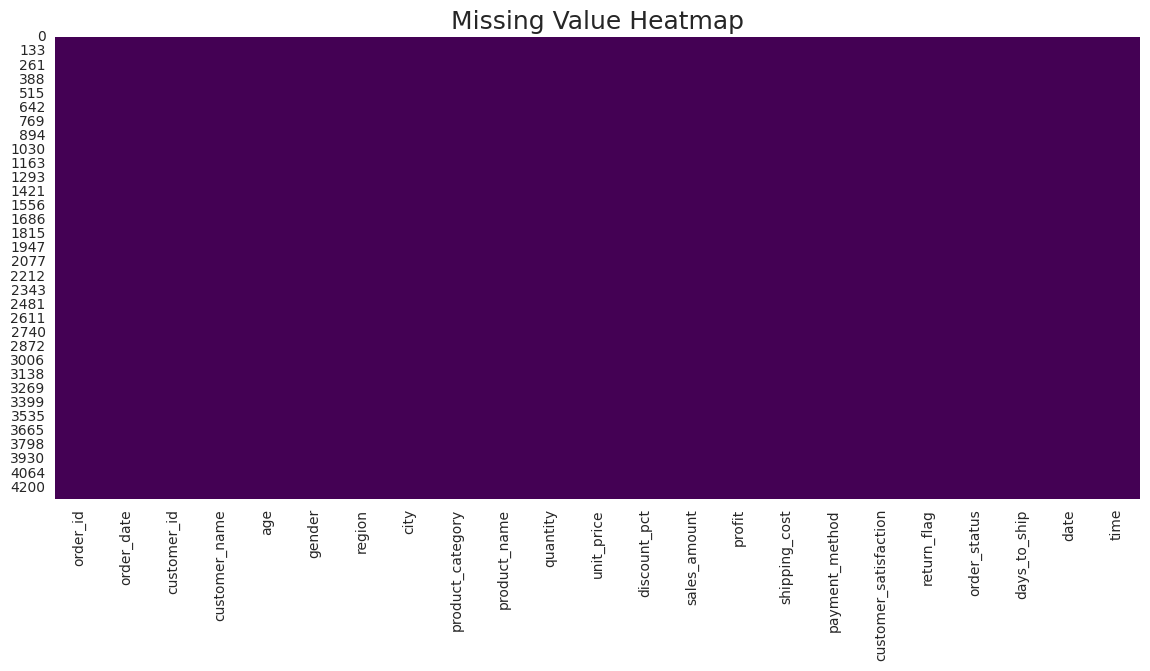

In [69]:
# Missing Value Heatmap
plt.figure(figsize=(14,6))

sns.heatmap(
    data.isnull(),
    cmap="viridis",
    cbar=False
)

plt.title("Missing Value Heatmap", fontsize=18)

plt.show()


In [80]:
region_sale = df.groupby('region')['sales_amount'].sum().sort_values(ascending=False)
region_sale

,sales_amount
region,
South,5.179297e+07
North,5.155429e+07
West,4.466677e+07
East,4.409088e+07
Central,3.682367e+07


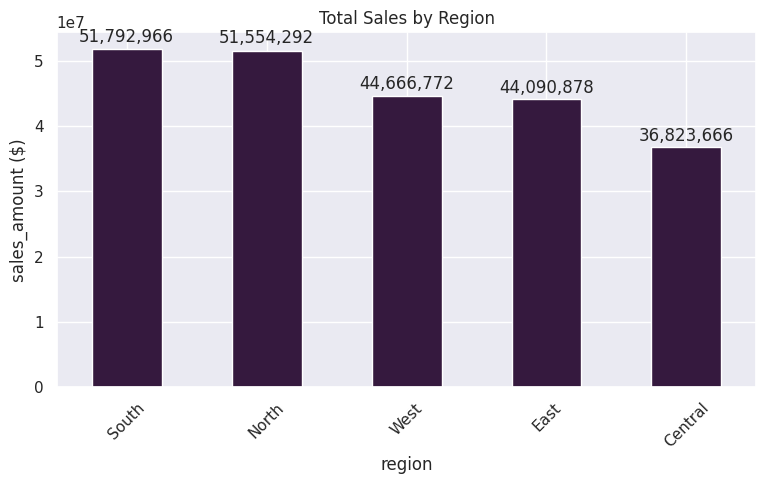

In [85]:
# TOP SALAES BY REGION
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 2)
bars = region_sale.plot(kind='bar', ax=plt.gca())  # Get current axes
plt.title('Total Sales by Region')
plt.xlabel('region')
plt.ylabel('sales_amount ($)')
plt.xticks(rotation=45)

# Add data labels only to bar chart
for i, v in enumerate(region_sale):
    plt.text(i, v + v*0.01, '{:,.0f}'.format(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [101]:
# top sales by categoru
top_category = df.groupby('product_category')['sales_amount'].sum().sort_values(ascending=False)

In [130]:
top_category
top_category.map('${:,.2f}'.format)

,sales_amount
product_category,
Electronics,"$127,364,097.36"
Furniture,"$53,031,743.51"
Sports,"$30,005,179.12"
Clothing,"$11,090,356.25"
Beauty,"$3,586,424.82"
Books,"$2,887,859.00"
Groceries,"$962,913.76"


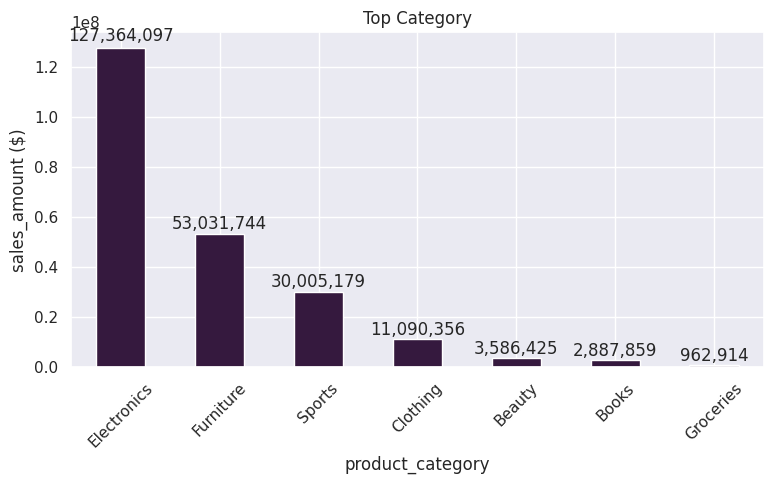

In [131]:
# TOP SALES BY CATEGORY

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 2)
bars = top_category.plot(kind='bar', ax=plt.gca())  # Get current axes
plt.title('Top Category')
plt.xlabel('product_category')
plt.ylabel('sales_amount ($)')
plt.xticks(rotation=45)

# Add data labels only to bar chart
for i, v in enumerate(top_category):
    plt.text(i, v + v*0.01, '{:,.0f}'.format(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [106]:
# Top Sales by gender
top_gender = df.groupby('gender')['sales_amount'].sum().sort_values(ascending=False)

In [108]:
top_gender.map('${:,.2f}'.format)

,sales_amount
gender,
Male,"$86,292,966.20"
Other,"$79,370,151.19"
Female,"$63,265,456.43"


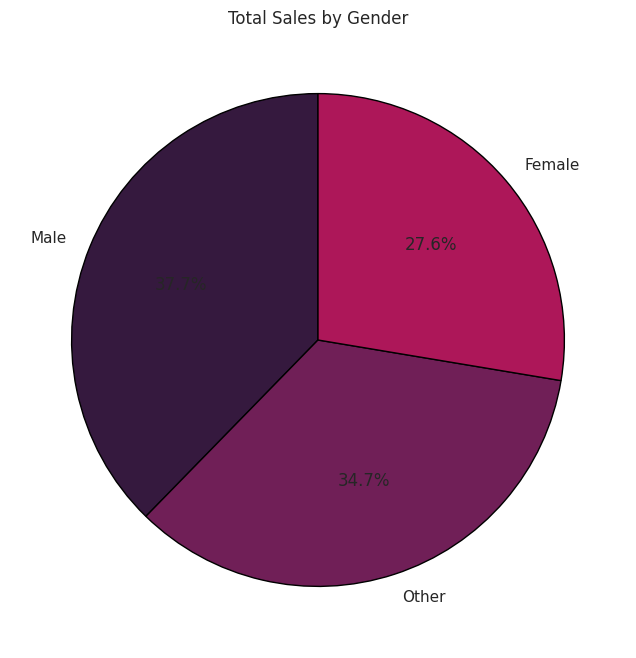

In [109]:
# TOP SALES BY GENDER
plt.figure(figsize=(8, 8))
plt.pie(top_gender, labels=top_gender.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Total Sales by Gender')
plt.show()

In [110]:
# Top customer sales
top_customer = df.groupby('customer_name')['sales_amount'].sum().sort_values(ascending=False)

In [112]:
top_customer.map('${:,.2f}'.format)

,sales_amount
customer_name,
Nisha Bhat,"$7,961,220.17"
Ananya Pillai,"$2,864,030.68"
Ritu Kapoor,"$2,622,448.52"
Nisha Joshi,"$2,360,876.34"
Meera Kapoor,"$2,098,684.16"
...,...
Sanjay Das,"$16,674.54"
Ananya Iyer,"$15,246.75"
Aarav Bhat,"$12,624.02"


In [113]:
top_customer.head(10)

,sales_amount
customer_name,
Nisha Bhat,7961220.17
Ananya Pillai,2864030.68
Ritu Kapoor,2622448.52
Nisha Joshi,2360876.34
Meera Kapoor,2098684.16
Rohan Mehta,2063836.76
Sanjay Rao,2060455.89
Amit Shah,1955359.66
Vikram Mishra,1837937.41


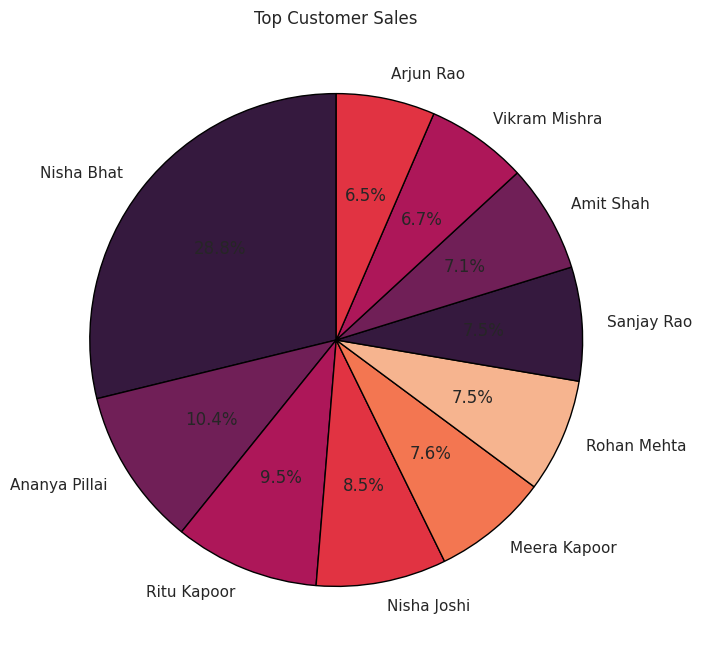

In [118]:
# TOP CUSTOMER SALES
plt.figure(figsize=(8, 8))
plt.pie(top_customer.head(10), labels=top_customer.head(10).index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Top Customer Sales')
plt.show()

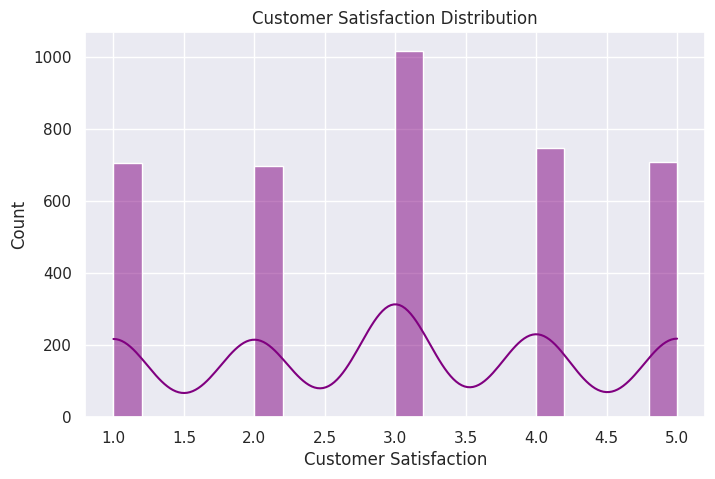

In [125]:
# CUSTOMER SATISFACTION
plt.figure(figsize=(8,5))

sns.histplot(
    data["customer_satisfaction"],
    bins=20,
    kde=True,
    color="purple"
)

plt.title("Customer Satisfaction Distribution")

plt.xlabel("Customer Satisfaction")

plt.show()

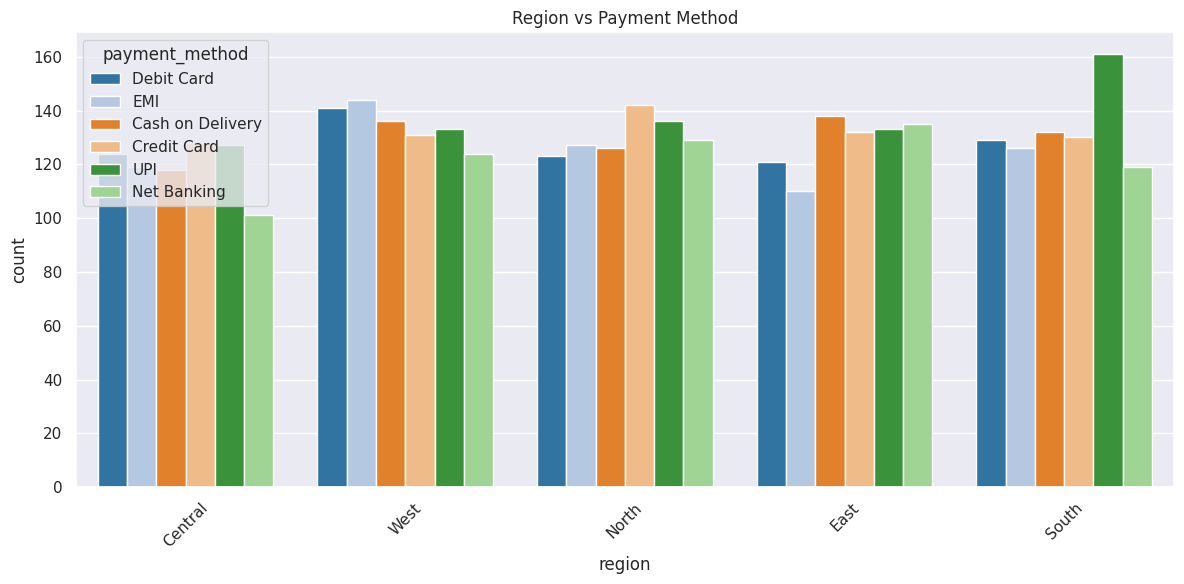

In [121]:
# REGION VS PAYMENT METHOD
plt.figure(figsize=(12,6))

sns.countplot(
    data=data,
    x="region",
    hue="payment_method",
    palette="tab20"
)

plt.title("Region vs Payment Method")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

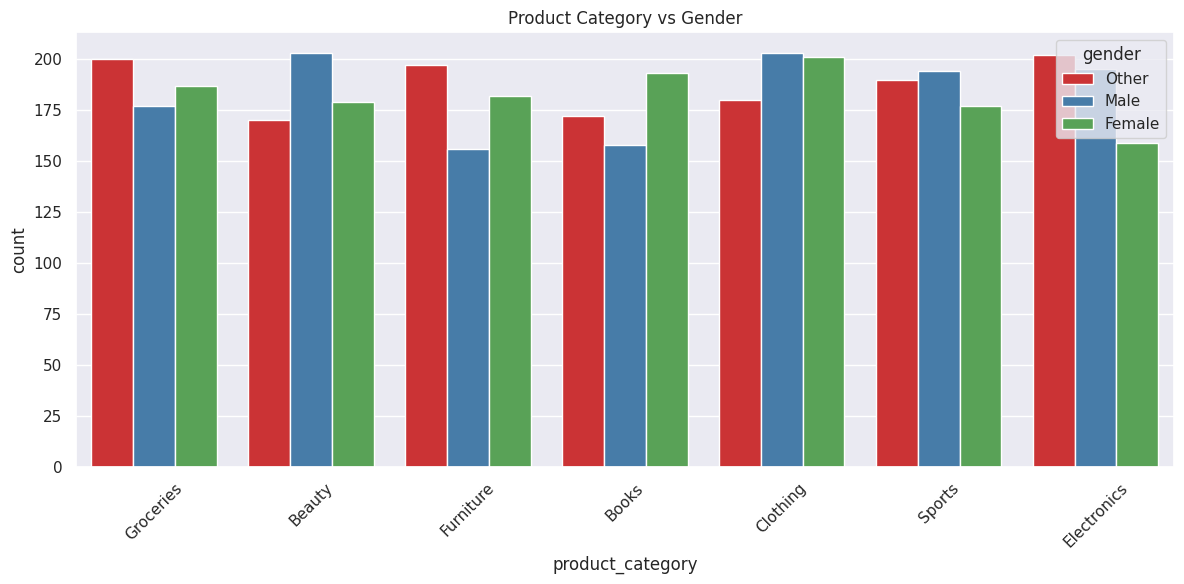

In [124]:
# PRODUCT CATEGORY VS GENDER

plt.figure(figsize=(12,6))

sns.countplot(
    data=data,
    x="product_category",
    hue="gender",
    palette="Set1"
)

plt.title("Product Category vs Gender")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [126]:
# Save DataFrame to a CSV file
df.to_csv('your_sales_data.csv', index=False)
print('DataFrame successfully saved to your_sales_data.csv')


DataFrame successfully saved to your_sales_data.csv


In [127]:
# Save DataFrame to an Excel file
df.to_excel('your_sales_data.xlsx', index=False)
print('DataFrame successfully saved to your_sales_data.xlsx')

DataFrame successfully saved to your_sales_data.xlsx
